In [1]:
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import sys
sys.path.insert(0, '/glade/u/home/dcalhoun/censuswxindex')
from censuswxindex import aggregate as wxagg

In [2]:
scratch = '/glade/derecho/scratch/dcalhoun'

In [3]:
shapefile_path = scratch + '/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'

In [15]:
dates = pd.date_range(start='2020-01-01', end='2024-01-01', freq='12h')
lead_times = [24]

In [6]:
fc_files = []
for init_time in dates:
    for lead_time in lead_times:
        date_str = init_time.strftime("%Y%m%d%H%M")
        year = date_str[:4]
        month = date_str[4:6]
        day = date_str[6:8]
        hour = date_str[8:]
        fc_path = glob.glob(scratch + f'/ecmwf/ifs/fc/0.125/2t/{hour}/{lead_time}/{year}/{month}/*{day}.nc')
        # Only append if a file was found (avoid empty file lists)
        if fc_path:
            fc_files.append((fc_path[0], str(init_time), lead_time))
n_files = len(fc_files)
print(n_files)

5846


In [16]:
idxs = [int(x) for x in np.random.choice(n_files, size=4, replace=False)]
for idx in idxs:
    print(fc_files[idx])

('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/1200/24/2023/06/ifs_fc_2t_1200_24_20230629.nc', '2023-06-29 12:00:00', 24)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/0000/24/2023/10/ifs_fc_2t_0000_24_20231019.nc', '2023-10-19 00:00:00', 24)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/1200/12/2022/04/ifs_fc_2t_1200_12_20220412.nc', '2022-04-12 12:00:00', 12)
('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/1200/12/2022/03/ifs_fc_2t_1200_12_20220303.nc', '2022-03-03 12:00:00', 12)


In [8]:
geo_agg = wxagg.GeoAggregator(shapefile_path=shapefile_path, grid_path=fc_files[0][0])

In [9]:
geo_agg

GeoAggregator
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
CRS: 'WGS84'

In [10]:
geo_agg.shapefile.columns

Index(['GISJOIN', 'STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ',
       'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP',
       'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'Shape_Leng', 'Shape_Area', 'ORIG_FID', 'geometry'],
      dtype='str')

In [17]:
fc_agg = wxagg.ForecastAggregator.from_geo_aggregator(geo_agg, forecast_files=[fc_files[idx] for idx in idxs], var_name="t2m")

In [18]:
fc_agg

ForecastAggregator
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
n_files: 4
init_times:
	2022-03-03 12:00:00
	2022-04-12 12:00:00
	2023-06-29 12:00:00
	2023-10-19 00:00:00
lead_times: [12, 24]
var_name: 't2m'
Coordinates:
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
CRS: 'WGS84'

In [19]:
df_fc = fc_agg.build_data_table()

In [20]:
len(df_fc)

12436

In [22]:
df_fc

,geo_id,valid_time,init_time,lead_time,t2m
0,01001,2023-06-30 12:00:00,2023-06-29 12:00:00,24,298.809502
1,01003,2023-06-30 12:00:00,2023-06-29 12:00:00,24,299.878396
2,01005,2023-06-30 12:00:00,2023-06-29 12:00:00,24,298.810669
3,01007,2023-06-30 12:00:00,2023-06-29 12:00:00,24,298.584275
4,01009,2023-06-30 12:00:00,2023-06-29 12:00:00,24,298.613478
...,...,...,...,...,...
12431,56037,2022-03-04 00:00:00,2022-03-03 12:00:00,12,278.493816
12432,56039,2022-03-04 00:00:00,2022-03-03 12:00:00,12,277.068559
12433,56041,2022-03-04 00:00:00,2022-03-03 12:00:00,12,279.645742
12434,56043,2022-03-04 00:00:00,2022-03-03 12:00:00,12,284.692306


In [23]:
fc_agg.save_data_table("test_fc.csv")

In [24]:
df_fc.groupby('valid_time').t2m.describe()

,count,mean,std,min,25%,50%,75%,max
valid_time,,,,,,,,
2022-03-04 00:00:00,3109.0,281.681348,9.904854,254.978051,274.056733,282.528449,290.245610,300.808042
2022-04-13 00:00:00,3109.0,289.706826,8.984775,261.252027,285.481285,292.448877,295.457464,310.958318
2023-06-30 12:00:00,3109.0,294.549095,4.423489,273.596811,292.506935,294.791078,298.077270,302.583567
2023-10-20 00:00:00,3109.0,290.167154,4.408741,278.495530,287.027659,289.289881,293.012468,310.833724


In [25]:
df_fc.groupby('lead_time').t2m.describe()

,count,mean,std,min,25%,50%,75%,max
lead_time,,,,,,,,
12,6218.0,285.694087,10.271633,254.978051,278.262205,288.914781,293.862534,310.958318
24,6218.0,292.358125,4.929514,273.596811,288.567401,292.678969,295.960668,310.833724


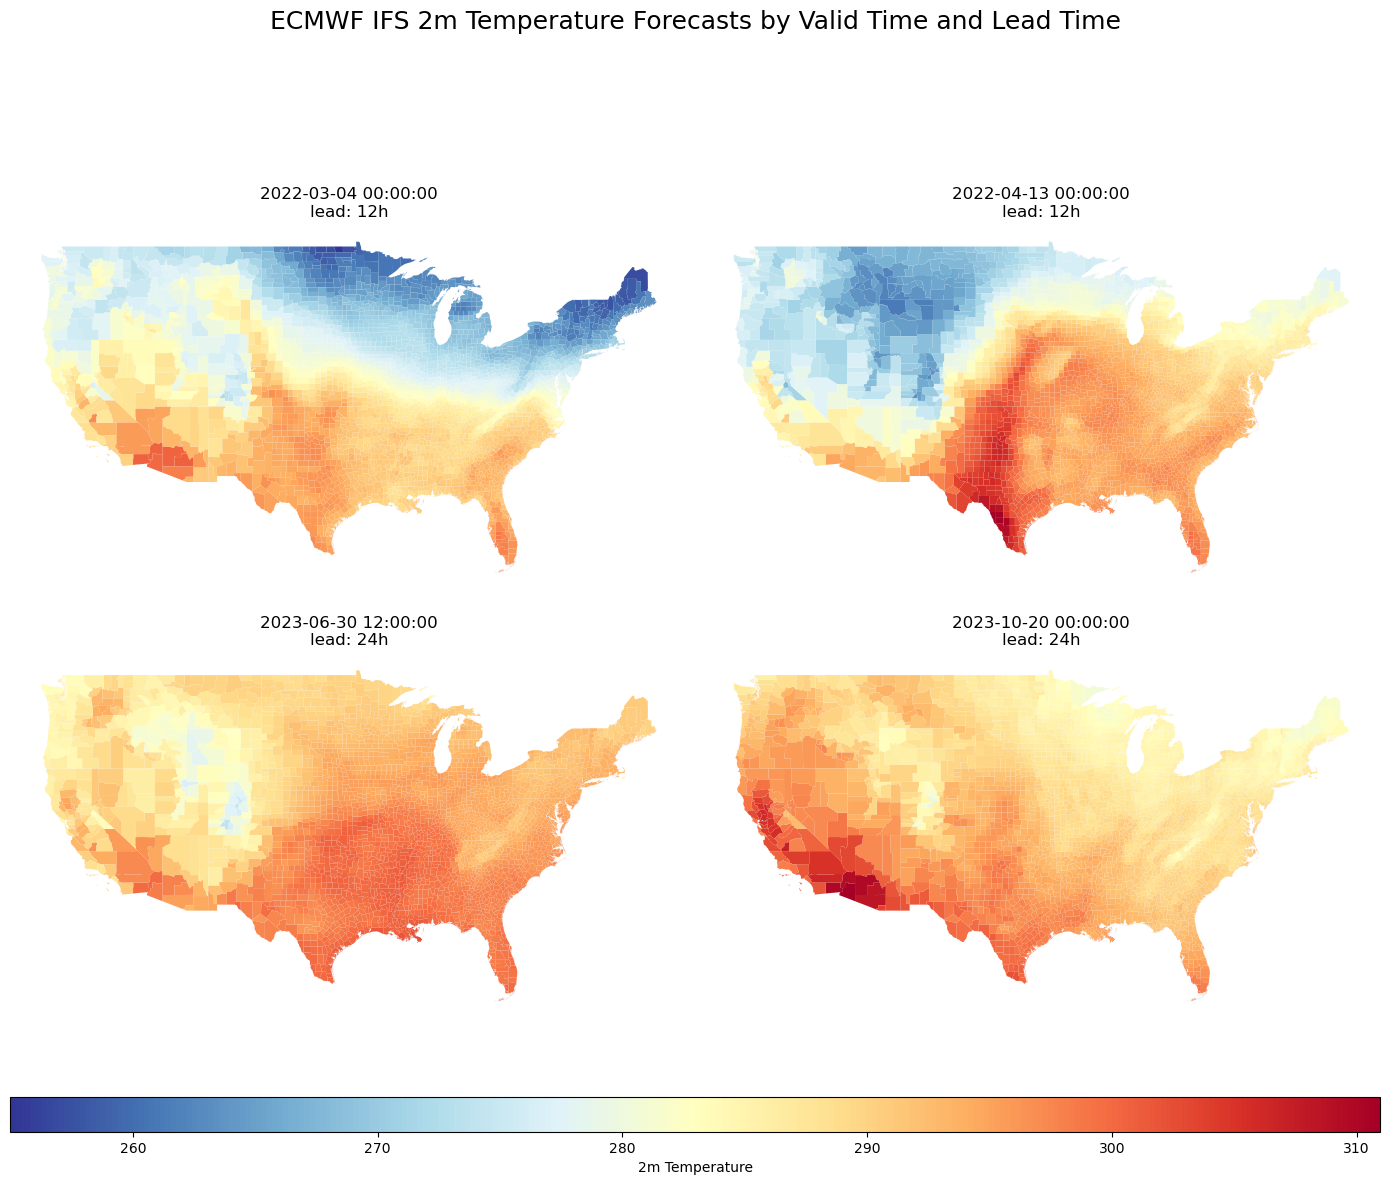

In [26]:
fc_agg.shapefile.rename(columns={'GEOID': 'geo_id'}, inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

vmin, vmax = df_fc['t2m'].min(), df_fc['t2m'].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = 'RdYlBu_r'

for ax, (valid_time, sub) in zip(axes, df_fc.groupby('valid_time')):
    gdf_plot = fc_agg.shapefile.merge(sub[['geo_id', 't2m']], on='geo_id', how='inner')
    gdf_plot.plot(ax=ax, column='t2m', cmap=cmap, norm=norm)
    lead_val = sub['lead_time'].iloc[0]
    ax.set_title(f'{valid_time}\nlead: {lead_val}h')
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.suptitle(
    'ECMWF IFS 2m Temperature Forecasts by Valid Time and Lead Time', 
    fontsize=18, 
    y=0.90  # Move title closer to panels
)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])  # Adjust for space at bottom for colorbar and a bit at top for title

fig.colorbar(
    sm,
    ax=axes.tolist(),
    orientation='horizontal',
    fraction=0.04,
    pad=0.07,
    aspect=40,
    label='2m Temperature'
)
plt.show()